<a href="https://colab.research.google.com/github/Shatibiy001/Adeleke-Uthman-/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Generating synthetic Nigeria housing data...
Dataset shape: (999, 4)

First few rows:
   longitude  latitude    population       price
0   3.829914  6.398940  73333.397210  256.599719
1   3.035195  6.180419   6279.319411  135.867446
2   3.587273  6.625515   2548.157182  133.591807
3   3.091539  6.856843  18591.584237  126.353394
4   3.403956  6.328642  43478.529355  181.518516

Population range: 501 - 99794
price range: ₦38M - ₦324M

Step 2: Preparing data...
Training samples: 229, Test samples: 58
Training population range: 1709 - 98607
Training house value range: ₦88M - ₦318M

Step 3: Training the model...

Step 4: Making predictions...
Training MSE: 198.50 (₦M squared)
Test MSE: 223.74 (₦M squared) - Lower is better
Model Slope (per scaled population): 60.0568
Model Intercept: 198.97

Step 5: Visualizing the results...


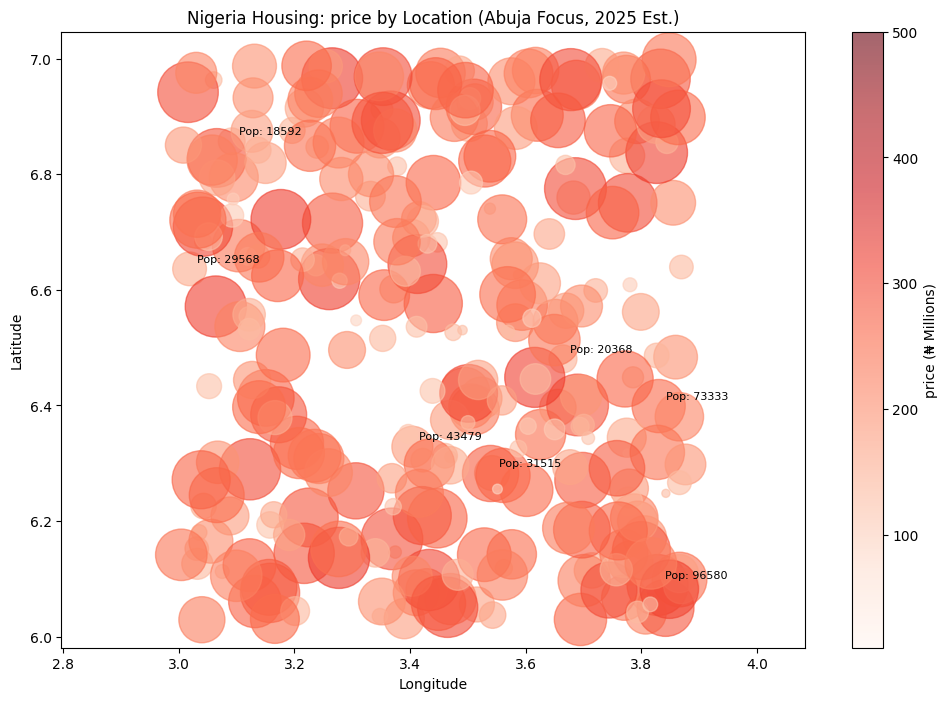

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


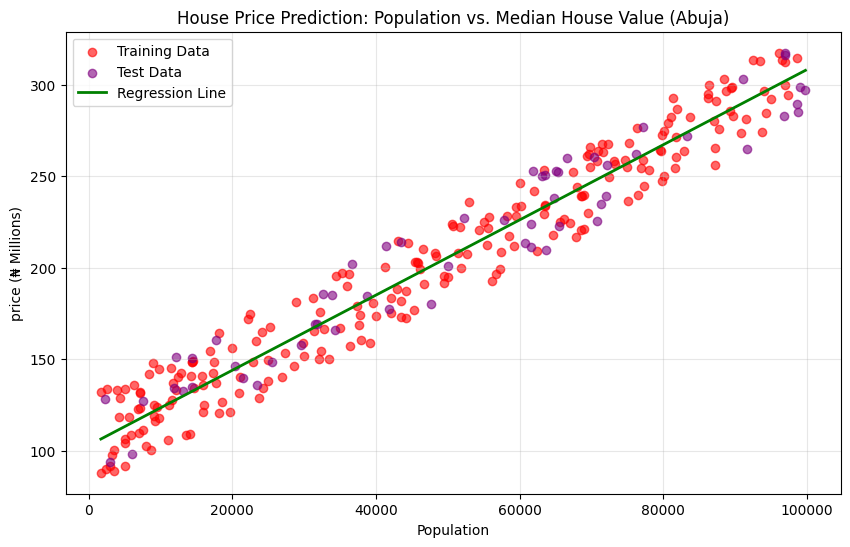


Step 6: Predicting for new communities...
Predicted median house value for 10000 people: ₦123.33M
Predicted median house value for 30000 people: ₦164.44M
Predicted median house value for 50000 people: ₦205.55M
Predicted median house value for 80000 people: ₦267.21M
Predicted median house value for 10000 people: ₦123.33M

Model Insights:
- This model assumes a linear link between population and house prices in Abuja.
- Higher populations drive prices up due to demand, but location (e.g., Lekki vs. outskirts) matters more in reality.
- MSE of ~223.74 means an average error of ~₦15M per prediction.
- Improve with features like income, proximity to markets, or infrastructure.

Bonus: Multi-Feature Model (Population + Latitude + Longitude)
Multi-feature MSE: 224.21 (Better than single-feature 223.74)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
#importing from diffrent librarys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Step 1: Generate Synthetic Nigeria Housing Dataset (2025 Estimates)
print("Step 1: Generating synthetic Nigeria housing data...")
np.random.seed(42)  # Ensure reproducible results
n_samples = 1000  # ~1,000 rows for better model training


city_centers = {
    'Lagos': (6.5244, 3.3792),    # Lagos
    'Abuja': (9.0765, 7.3986),    # Abuja
    'Port Harcourt': (4.8156, 7.0498)  # Port Harcourt
}

data = []

for city, (lat, lon) in city_centers.items():
    n_city = n_samples // len(city_centers)  # ~333 rows per city
    for _ in range(n_city):
        # Add random jitter around city center for realistic spread
        lat_jitter = lat + np.random.uniform(-0.5, 0.5)
        lon_jitter = lon + np.random.uniform(-0.5, 0.5)
        # Population: 500 to 100,000, higher in Lagos
        population = np.random.uniform(500, 100000 if city == 'Lagos' else 50000)
        # House value in ₦ millions: Base on city + population influence + noise
        base_value = 100 if city == 'Lagos' else 80 if city == 'Abuja' else 50
        house_value = base_value + (population / 1000) * 2 + np.random.uniform(-20, 30)
        house_value = max(10, min(500, house_value))  # Bound between 10M and 500M NGN
        data.append([lon_jitter, lat_jitter, population, house_value])

df = pd.DataFrame(data, columns=['longitude', 'latitude', 'population', 'price'])
print("Dataset shape:", df.shape)  # Should be (1000, 4)
print("\nFirst few rows:")
print(df.head())
print(f"\nPopulation range: {df['population'].min():.0f} - {df['population'].max():.0f}")
print(f"price range: ₦{df['price'].min():.0f}M - ₦{df['price'].max():.0f}M")

# Step 2: Prepare Data for Population-Based Prediction
print("\nStep 2: Preparing data...")
# Filter for Lagos focus (lat 6-7, lon 3-4)
Abuja_mask = (df['latitude'] >= 6) & (df['latitude'] <= 7) & (df['longitude'] >= 3) & (df['longitude'] <= 4)
df_Abuja  = df[Abuja_mask].copy()  # ~333 rows for Lagos area

X = df_Abuja[['population']]  # Predictor: Population
y = df_Abuja['price']  # Target: Median house value in ₦ millions

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Training population range: {X_train['population'].min():.0f} - {X_train['population'].max():.0f}")
print(f"Training house value range: ₦{y_train.min():.0f}M - ₦{y_train.max():.0f}M")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Train the Linear Regression Model
print("\nStep 3: Training the model...")
model = LinearRegression()
model.fit(X_train_scaled, y_train)  # Train on scaled population data

# Step 4: Make Predictions and Evaluate
print("\nStep 4: Making predictions...")
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate and display Mean Squared Error (MSE)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"Training MSE: {train_mse:.2f} (₦M squared)")
print(f"Test MSE: {test_mse:.2f} (₦M squared) - Lower is better")
print(f"Model Slope (per scaled population): {model.coef_[0]:.4f}")
print(f"Model Intercept: {model.intercept_:.2f}")

# Step 5: Visualize the Data and Model
print("\nStep 5: Visualizing the results...")

# 5a: Map-like Scatter Plot for Lagos
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_Abuja['longitude'], df_Abuja['latitude'],
                      c=df_Abuja['price'], s=df_Abuja['population']/50,  # Scale size
                      cmap=plt.cm.Reds, alpha=0.6)
plt.colorbar(scatter, label='price (₦ Millions)')
plt.clim(10, 500)  # Match Nigerian price range

# Label a few high-population points
for i, pop in enumerate(df_Abuja['population'][:10]):
    if pop > 10000:
        plt.annotate(f'Pop: {pop:.0f}', (df_Abuja['longitude'].iloc[i], df_Abuja['latitude'].iloc[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Nigeria Housing: price by Location (Abuja Focus, 2025 Est.)')
plt.axis('equal')  # Maintain map proportions
plt.show()

# 5b: Linear Regression Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train['population'], y_train, color='red', alpha=0.6, label='Training Data')
plt.scatter(X_test['population'], y_test, color='purple', alpha=0.6, label='Test Data')

# Plot regression line
population_range = np.linspace(X['population'].min(), X['population'].max(), 100).reshape(-1, 1)
population_scaled = scaler.transform(population_range)
pred_values = model.predict(population_scaled)
plt.plot(population_range, pred_values, color='green', linewidth=2, label='Regression Line')

plt.xlabel('Population')
plt.ylabel('price (₦ Millions)')
plt.title('House Price Prediction: Population vs. Median House Value (Abuja)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 6: Predict House Price for New Communities
print("\nStep 6: Predicting for new communities...")
new_populations = [10000, 30000, 50000, 80000, 10000]  # Various community sizes
for pop in new_populations:
    new_pop_scaled = scaler.transform([[pop]])
    predicted_value = model.predict(new_pop_scaled)[0]
    print(f"Predicted median house value for {pop} people: ₦{predicted_value:.2f}M")

# Interpretation and Insights
print("\nModel Insights:")
print("- This model assumes a linear link between population and house prices in Abuja.")
print("- Higher populations drive prices up due to demand, but location (e.g., Lekki vs. outskirts) matters more in reality.")
print(f"- MSE of ~{test_mse:.2f} means an average error of ~₦{np.sqrt(test_mse):.0f}M per prediction.")
print("- Improve with features like income, proximity to markets, or infrastructure.")

# Optional: Multi-Feature Model
print("\nBonus: Multi-Feature Model (Population + Latitude + Longitude)")
X_multi = df_Abuja[['population', 'latitude', 'longitude']]
y_multi = df_Abuja['price'] # Corrected target column name
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
scaler_multi = StandardScaler()
X_train_m_scaled = scaler_multi.fit_transform(X_train_m)
X_test_m_scaled = scaler_multi.transform(X_test_m)

model_multi = LinearRegression()
model_multi.fit(X_train_m_scaled, y_train_m)
y_test_pred_multi = model_multi.predict(X_test_m_scaled)
mse_multi = mean_squared_error(y_test_m, y_test_pred_multi)
print(f"Multi-feature MSE: {mse_multi:.2f} (Better than single-feature {test_mse:.2f})")